In [1]:
import pandas as pd
import os

import matplotlib.pyplot as plt

# Define Global Variables

In [ ]:
cli_args = dict(
    # LSTM PARAMS
    data='dundee',  # dundee | porto | boulder | paloalto
    # DATA PARAMS
    sr_freq='12H', 
    min_pts=100,
    variant = 'light'   # heavy | light
)

In [3]:
if cli_args['data'] == 'dundee':
    EVSE_OID = 50692
elif cli_args['data'] == 'porto':
    EVSE_OID = 'inescevse007'
elif cli_args['data'] == 'boulder':
    EVSE_OID = 'BOULDER / REC CENTER ST2'
elif cli_args['data'] == 'paloalto':
    EVSE_OID = 'PALO ALTO CA / CAMBRIDGE #2'

# Load Dataset

In [4]:
df_evse_demand_v3 = pd.read_pickle(
    os.path.join(
        '../data', 'pkl', 
        f"{cli_args['data']}_data.demand_{cli_args['sr_freq']}_{cli_args['min_pts']}_points.enriched.v4.pickle"
    )
).sort_index()

# Load forecasting results / metrics from federated ML-based models

In [5]:
fededf_results_lstm = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__Fed{"LSTM"}_{cli_args["variant"]}__model.v4.pickle')
fededf_results_gru = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__Fed{"GRU"}_{cli_args["variant"]}__model.v4.pickle')
fededf_results_bilstm = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__Fed{"BiLSTM"}_{cli_args["variant"]}__model.v4.pickle')
fededf_results_bigru = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__Fed{"BiGRU"}_{cli_args["variant"]}__model.v4.pickle')

fededf_results_xgb_og = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__{"FedXGBllr__mu_prox_0.0"}_{cli_args["variant"]}__model.v4.pickle')
fededf_results_xgb_prox = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__{"FedXGBllr__mu_prox_0.1"}_{cli_args["variant"]}__model.v4.pickle')

In [ ]:
fededf_metrics_lstm = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__Fed{"LSTM"}_{cli_args["variant"]}__model.metrics.v4.pickle')
fededf_metrics_gru = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__Fed{"GRU"}_{cli_args["variant"]}__model.metrics.v4.pickle')
fededf_metrics_bilstm = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__Fed{"BiLSTM"}_{cli_args["variant"]}__model.metrics.v4.pickle')
fededf_metrics_bigru = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__Fed{"BiGRU"}_{cli_args["variant"]}__model.metrics.v4.pickle')

fededf_metrics_xgb_og = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__{"FedXGBllr__mu_prox_0.0"}_{cli_args["variant"]}__model.metrics.v4.pickle')
fededf_metrics_xgb_prox = pd.read_pickle(f'../data/pkl/{cli_args["data"]}_data.demand_{cli_args["sr_freq"]}.EVSE__{"FedXGBllr__mu_prox_0.1"}_{cli_args["variant"]}__model.metrics.v4.pickle')

# Visualize results

In [6]:
fededf_preds = fededf_results_lstm.join(
    fededf_results_gru.drop('power_next', axis=1)
).join(
    fededf_results_bilstm.drop('power_next', axis=1)
).join(
    fededf_results_bigru.drop('power_next', axis=1)
).join(
    fededf_results_xgb_og.drop('power_next', axis=1)
).join(
    fededf_results_xgb_prox.drop('power_next', axis=1)
)

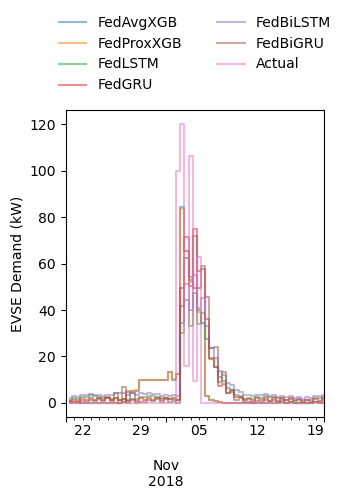

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(3.5, 5.5), sharex=True)


fededf_preds.loc[
    pd.IndexSlice[
        EVSE_OID, 
        :
    ], 
    ['FedXGBllr__mu_prox_0.0', 'FedXGBllr__mu_prox_0.1', 'LSTM', 'GRU', 'biLSTM', 'biGRU', *(['power_next',] if cli_args['data'] != 'porto' else [])]
].reset_index(level=0, drop=True).plot(drawstyle='steps-mid', alpha=0.5, ax=ax)


if cli_args['data'] == 'dundee':
    ax.set_xlim(
        '2018-10-20',
        '2018-11-20',
    )

elif cli_args['data'] == 'porto':
    df_evse_demand_v3['power_curr'].shift(-1).loc[
        pd.IndexSlice[
            :, 
            EVSE_OID, 
            '2025-05-16 12:00:00':'2025-06-20 00:00:00'
        ]
    ].reset_index(
        level=(0,1), 
        drop=True
    ).plot(
        drawstyle='steps-mid', 
        alpha=0.5,
        ax=ax,
    )

    ax.set_xlim(
        '2025-05-23',
        '2025-06-20',
    )

elif cli_args['data'] == 'boulder':
    ax.set_xlim(
        '2021-03-01',
        '2021-03-30',
    )

elif cli_args['data'] == 'paloalto':
    ax.set_xlim(
        '2020-10-01',
        '2020-10-30',
    )


ax.set_xlabel(None)
ax.set_ylabel('EVSE Demand (kW)')

plt.legend(['FedAvgXGB', 'FedProxXGB', 'FedLSTM', 'FedGRU', 'FedBiLSTM', 'FedBiGRU', 'Actual'], ncol=2, loc='upper center', columnspacing=2.5, bbox_to_anchor=(0.5, 1.35), frameon=False)

plt.tight_layout()
plt.savefig(f'../data/fig/{cli_args["data"]}-fed-xgb-lstm-{str(EVSE_OID).replace(" / ", "_")}-test-set.{cli_args["variant"]}.v8.pdf', dpi=300)

# Illustrate metric results

In [ ]:
fededf_metrics = fededf_metrics_lstm.join(
    fededf_metrics_gru
).join(
    fededf_metrics_bilstm
).join(
    fededf_metrics_bigru
).join(
    fededf_metrics_xgb_og
).join(
    fededf_metrics_xgb_prox
).groupby(level=0).describe().T

In [10]:
fededf_metrics.loc[
    pd.IndexSlice[:, ['25%', '50%', '75%']], 
    ['0_MASE_pct', '1_SMAPE_pct', '2_MAAPE_rads', '3_WAPE_pct', '4_RMSE_kW', '5_MAE_kW', '6_R2']
].round(4)

0_MASE_pct  1_SMAPE_pct  2_MAAPE_rads  3_WAPE_pct  \
LSTM                   25%      0.2666       1.7044        1.3205      1.2996   
                       50%      0.3617       1.8071        1.4044      2.0016   
                       75%      0.5386       1.9124        1.4865      2.9872   
GRU                    25%      0.3105       1.8668        1.4546      1.4442   
                       50%      0.4194       1.9050        1.4846      2.3127   
                       75%      0.5600       1.9465        1.5164      3.5296   
biLSTM                 25%      0.3874       1.8797        1.4725      1.8151   
                       50%      0.4982       1.9110        1.4894      2.6796   
                       75%      0.6496       1.9441        1.5181      3.9609   
biGRU                  25%      0.1996       1.4881        1.1528      1.2323   
                       50%      0.3174       1.7827        1.3768      1.6136   
                       75%      0.4532       1.8942        1.4810      2.2142   
FedXGBllr__mu_prox_0.0 25%      0.3139       1.1313        0.8874      1.2199   
                       50%      0.4835       1.3093        1.0201      3.2680   
                       75%      0.7537       1.5929        1.2634      6.1207   
FedXGBllr__mu_prox_0.1 25%      0.3157       1.1313        0.8876      1.2258   
                       50%      0.4886       1.3095        1.0202      3.2892   
                       75%      0.7602       1.5932        1.2637      6.1488   

                            4_RMSE_kW  5_MAE_kW    6_R2  
LSTM                   25%     1.3918    0.6285 -0.0665  
                       50%     2.7272    1.3015  0.0845  
                       75%     5.3315    2.6207  0.2666  
GRU                    25%     1.5063    0.7567 -0.1146  
                       50%     2.9084    1.4860  0.0357  
                       75%     5.2746    3.1288  0.2814  
biLSTM                 25%     1.5359    0.8996 -0.2851  
                       50%     2.8561    1.6524  0.0152  
                       75%     5.5386    3.0692  0.2107  
biGRU                  25%     1.3553    0.4641  0.0041  
                       50%     2.7930    1.2962  0.1410  
                       75%     5.3503    2.6743  0.2891  
FedXGBllr__mu_prox_0.0 25%     2.7524    1.1602 -6.0089  
                       50%     4.1179    1.9608 -1.1073  
                       75%     6.2049    3.2234  0.2792  
FedXGBllr__mu_prox_0.1 25%     2.7576    1.1757 -5.9854  
                       50%     4.1438    1.9809 -1.1264  
                       75%     6.2229    3.2581  0.2830

In [ ]:
# For LaTeX
print(
    fededf_metrics.loc[
        pd.IndexSlice[['FedXGBllr__mu_prox_0.0', 'FedXGBllr__mu_prox_0.1', 'LSTM', 'GRU', 'biLSTM', 'biGRU'], ['25%', '50%', '75%']], 
        ['0_MASE_pct', '1_SMAPE_pct', '2_MAAPE_rads', '3_WAPE_pct', '4_RMSE_kW', '5_MAE_kW', '6_R2']
    ].round(2).groupby(level=0, sort=False).apply(
        lambda l: l.apply(
            lambda k: '; '.join(k.values.astype(str).tolist())
        )
    ).to_latex()
)

\begin{tabular}{llllllll}
\toprule
 & 0_MASE_pct & 1_SMAPE_pct & 2_MAAPE_rads & 3_WAPE_pct & 4_RMSE_kW & 5_MAE_kW & 6_R2 \\
\midrule
FedXGBllr__mu_prox_0.0 & 0.31; 0.48; 0.75 & 1.13; 1.31; 1.59 & 0.89; 1.02; 1.26 & 1.22; 3.27; 6.12 & 2.75; 4.12; 6.2 & 1.16; 1.96; 3.22 & -6.01; -1.11; 0.28 \\
FedXGBllr__mu_prox_0.1 & 0.32; 0.49; 0.76 & 1.13; 1.31; 1.59 & 0.89; 1.02; 1.26 & 1.23; 3.29; 6.15 & 2.76; 4.14; 6.22 & 1.18; 1.98; 3.26 & -5.99; -1.13; 0.28 \\
LSTM & 0.27; 0.36; 0.54 & 1.7; 1.81; 1.91 & 1.32; 1.4; 1.49 & 1.3; 2.0; 2.99 & 1.39; 2.73; 5.33 & 0.63; 1.3; 2.62 & -0.07; 0.08; 0.27 \\
GRU & 0.31; 0.42; 0.56 & 1.87; 1.91; 1.95 & 1.45; 1.48; 1.52 & 1.44; 2.31; 3.53 & 1.51; 2.91; 5.27 & 0.76; 1.49; 3.13 & -0.11; 0.04; 0.28 \\
biLSTM & 0.39; 0.5; 0.65 & 1.88; 1.91; 1.94 & 1.47; 1.49; 1.52 & 1.82; 2.68; 3.96 & 1.54; 2.86; 5.54 & 0.9; 1.65; 3.07 & -0.29; 0.02; 0.21 \\
biGRU & 0.2; 0.32; 0.45 & 1.49; 1.78; 1.89 & 1.15; 1.38; 1.48 & 1.23; 1.61; 2.21 & 1.36; 2.79; 5.35 & 0.46; 1.3; 2.67 & 0.0; 0